In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from privacy_amplification_experiments import run_privacy_amplification_parameter_sweep

In [2]:
df = run_privacy_amplification_parameter_sweep(
    n=10000,
    trials_per_setting=10,
    compression_ratios=[0.25, 0.40, 0.50, 0.75, 0.90],
    message_lengths_chars=[16, 64, 128, 256],
    eve_intercept_prob=0.03,
    channel_noise_prob=0.01,
    qber_threshold=0.11,
    error_correction_block_size=16,
    error_correction_passes=10
)

df

,message_length_chars,message_bits_required,privacy_compression_ratio,eve_intercept_prob,channel_noise_prob,qber_threshold,trials_per_setting,qubits_per_trial,success_rate,average_qber,average_reconciled_key_length,average_final_key_capacity,insufficient_key_failures,mismatch_failures,qber_failures
0,16,128,0.25,0.03,0.01,0.11,10,10000,1.0,0.017093,4984.9,1245.8,0,0,0
1,16,128,0.40,0.03,0.01,0.11,10,10000,1.0,0.017344,4996.1,1998.2,0,0,0
2,16,128,0.50,0.03,0.01,0.11,10,10000,1.0,0.016190,5002.6,2501.0,0,0,0
3,16,128,0.75,0.03,0.01,0.11,10,10000,1.0,0.016109,5008.2,3755.8,0,0,0
4,16,128,0.90,0.03,0.01,0.11,10,10000,1.0,0.017003,5004.8,4504.0,0,0,0
5,64,512,0.25,0.03,0.01,0.11,10,10000,1.0,0.017950,5008.3,1251.8,0,0,0
6,64,512,0.40,0.03,0.01,0.11,10,10000,1.0,0.017827,4991.6,1996.2,0,0,0
7,64,512,0.50,0.03,0.01,0.11,10,10000,1.0,0.016878,5016.4,2507.9,0,0,0
8,64,512,0.75,0.03,0.01,0.11,10,10000,1.0,0.016997,4982.0,3736.0,0,0,0
9,64,512,0.90,0.03,0.01,0.11,10,10000,1.0,0.017330,5018.5,4516.4,0,0,0


In [3]:
df.to_csv("../results/privacy_amplification_parameter_sweep.csv", index=False)

print("Saved results to ../results/privacy_amplification_parameter_sweep.csv")

Saved results to ../results/privacy_amplification_parameter_sweep.csv


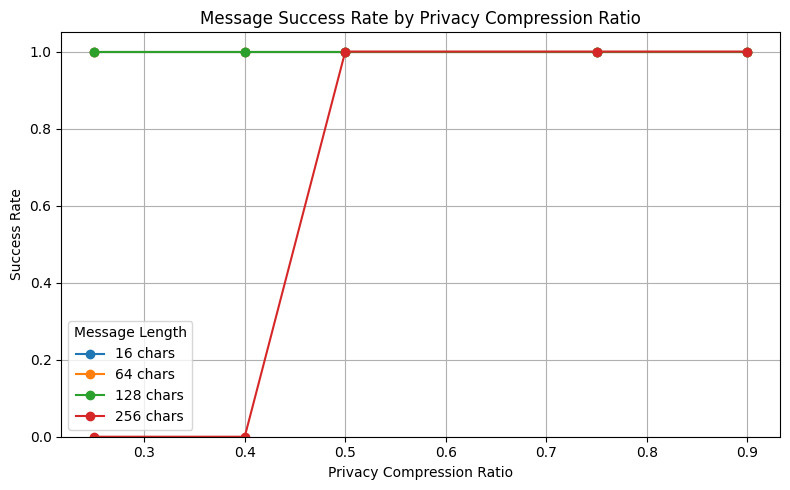

In [4]:
plt.figure(figsize=(8, 5))

for message_length in sorted(df["message_length_chars"].unique()):
    subset = df[df["message_length_chars"] == message_length]

    plt.plot(
        subset["privacy_compression_ratio"],
        subset["success_rate"],
        marker="o",
        label=f"{message_length} chars"
    )

plt.xlabel("Privacy Compression Ratio")
plt.ylabel("Success Rate")
plt.title("Message Success Rate by Privacy Compression Ratio")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(title="Message Length")
plt.tight_layout()

plt.savefig("../figures/privacy_amplification_success_rate.png", dpi=300)
plt.show()

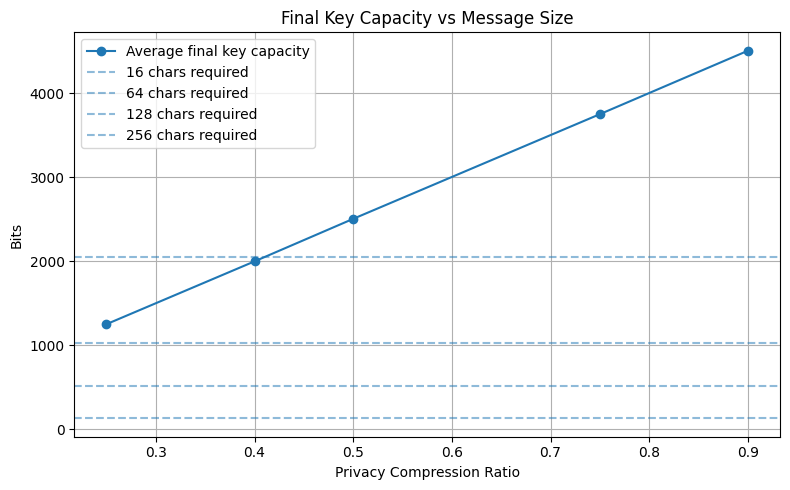

In [5]:
capacity_df = (
    df.groupby("privacy_compression_ratio")["average_final_key_capacity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    capacity_df["privacy_compression_ratio"],
    capacity_df["average_final_key_capacity"],
    marker="o",
    label="Average final key capacity"
)

for message_length in sorted(df["message_length_chars"].unique()):
    message_bits = int(
        df[df["message_length_chars"] == message_length]["message_bits_required"].iloc[0]
    )

    plt.axhline(
        message_bits,
        linestyle="--",
        alpha=0.5,
        label=f"{message_length} chars required"
    )

plt.xlabel("Privacy Compression Ratio")
plt.ylabel("Bits")
plt.title("Final Key Capacity vs Message Size")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("../figures/privacy_amplification_key_capacity.png", dpi=300)
plt.show()

## Privacy Amplification Parameter Sweep

This notebook studies how the privacy amplification compression ratio affects message transmission.

The experiment varies:

- privacy compression ratio
- message length

For each setting, it records the success rate, average reconciled key length, average final key capacity, and failure causes.

The goal is to understand the tradeoff created by privacy amplification. Stronger compression reduces the amount of usable final key material, while weaker compression preserves more usable key length.